Saving Final_Cleaned_EC2_Instances (2).csv to Final_Cleaned_EC2_Instances (2) (2).csv
You uploaded: Final_Cleaned_EC2_Instances (2) (2).csv
Dataset loaded: (402, 20)

Columns:
['Instance type', 'Release Date', 'Instance vCPU', 'Platform Total Number of vCPU', 'Platform CPU Name', 'Instance Memory (in GB)', 'Platform Memory (in GB)', 'Storage Type', 'Platform Storage Drive Quantity', 'RAMWatt @ Idle', 'RAMWatt @ 10%', 'RAMWatt @ 50%', 'RAMWatt @ 100%', 'Delta Full Machine', 'Platform Additional Memory Scope 3 Emissions', 'Platform Additional Storage Scope 3 Emissions', 'Platform Additional GPU Scope 3 Emissions', 'Platform Additional CPU Scope 3 Emissions', 'Total Platform Scope 3 Emissions  (kgCO?eq)', 'Instance Hourly Manufacturing Emissions (gCO?eq)']

 Using columns:
CPU name  : Platform CPU Name
Idle watt : RAMWatt @ Idle
Full watt : Delta Full Machine
vCPU      : Instance vCPU
Scope 3   : Total Platform Scope 3 Emissions  (kgCO?eq)

⚡ STEP 3 – Energy calculations

🔍 Sample energy 

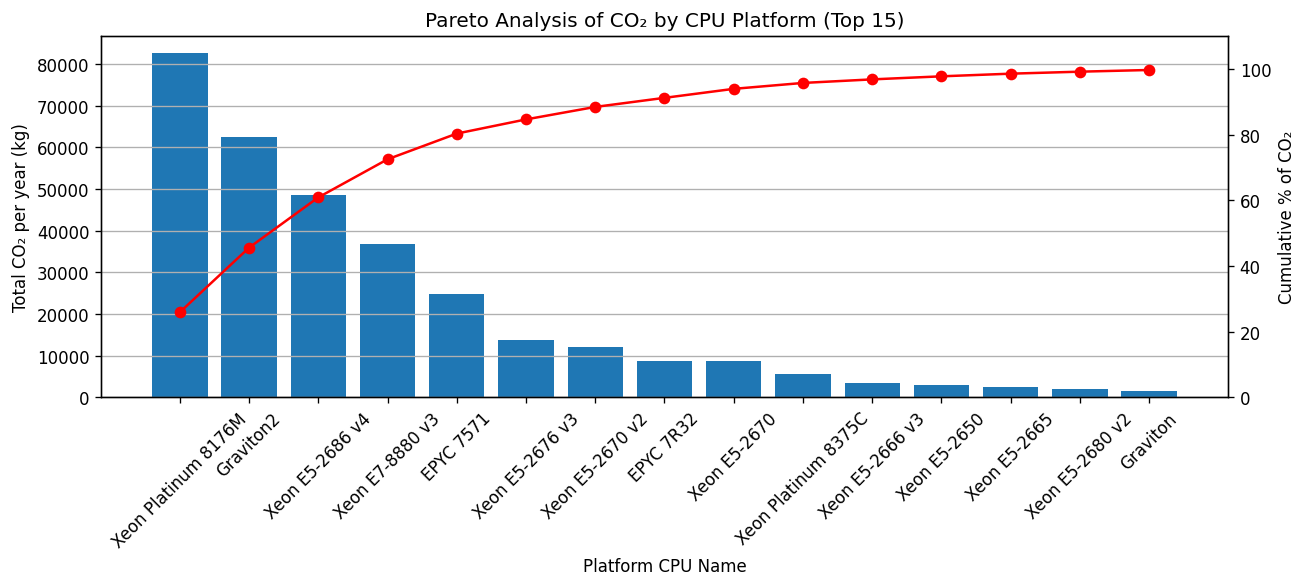


 STEP 8 – Graphs for ALL CPU platforms


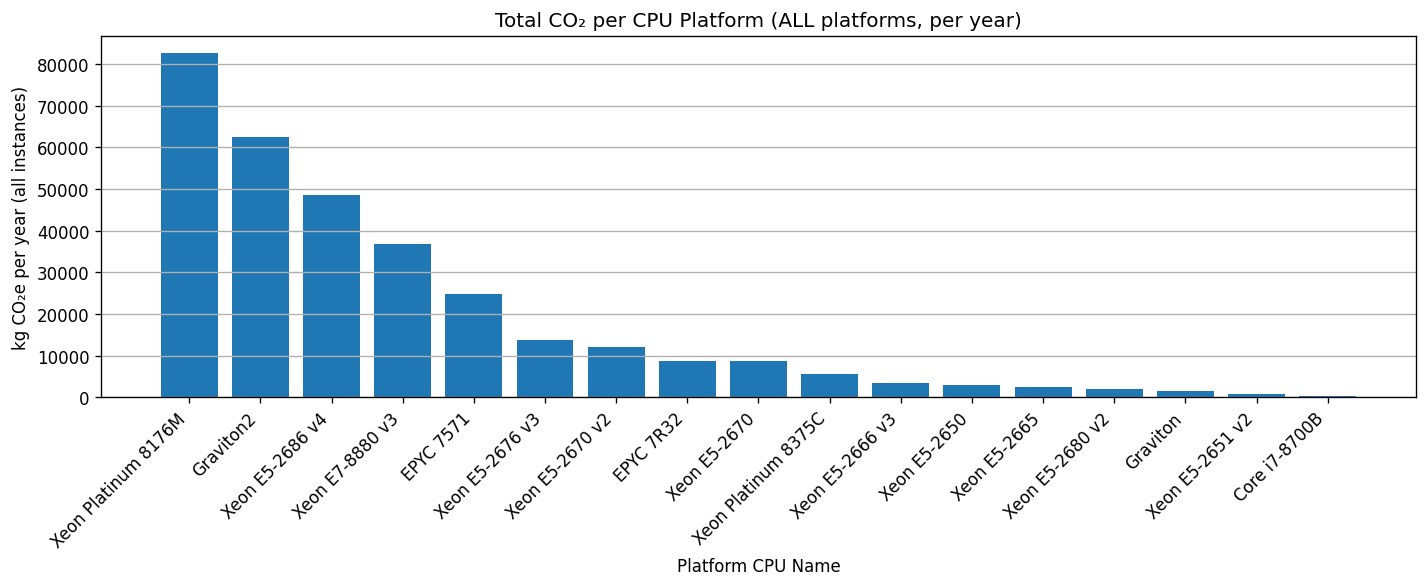

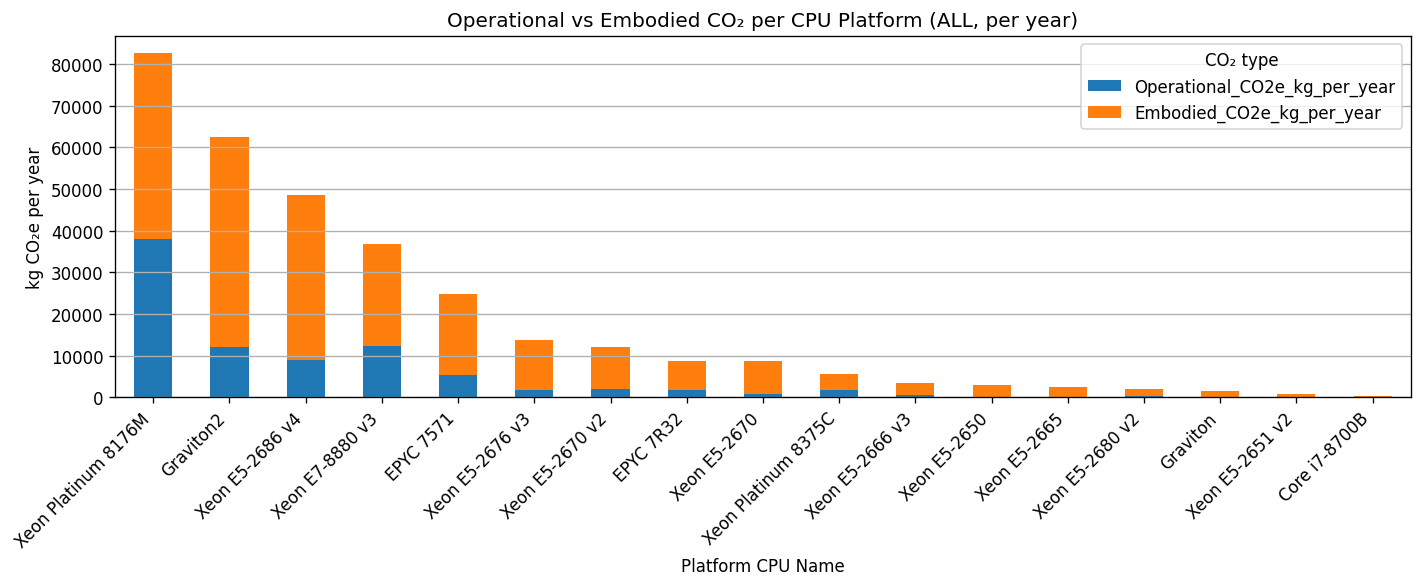

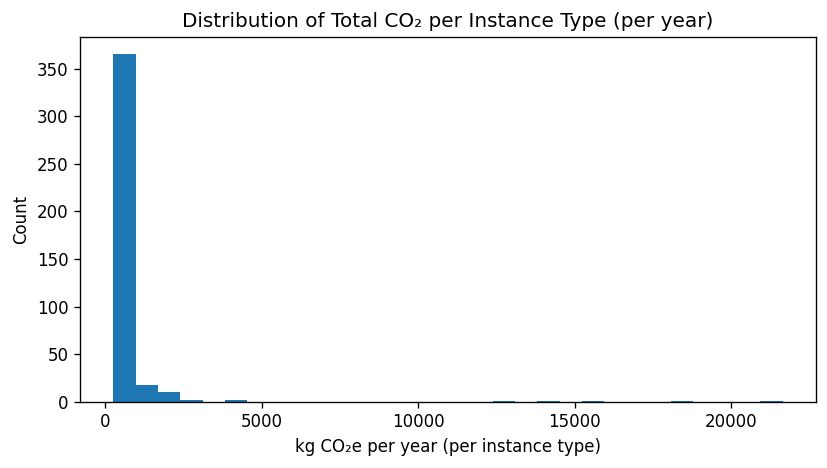

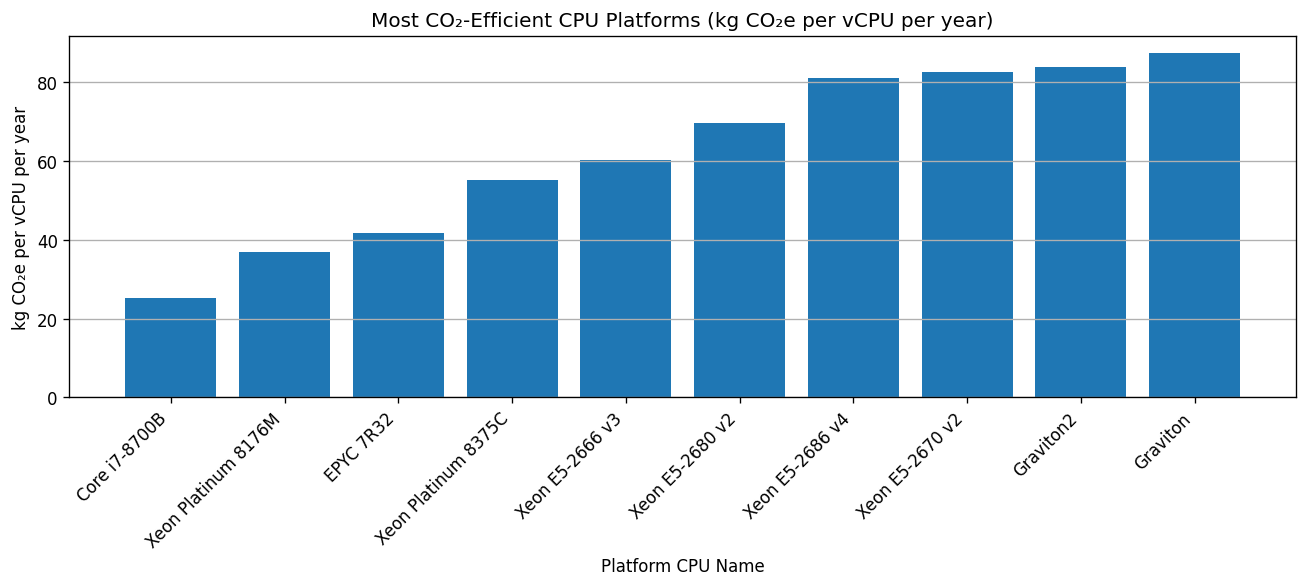


 STEP 9 – Lean Scenario 1: Improve PUE from 1.4 to 1.2
Total CO₂ per year (PUE 1.4) : 318,377.49 kg
Total CO₂ per year (PUE 1.2) : 306,032.13 kg
CO₂ saved by better PUE      : 12,345.36 kg (3.9% reduction)

 STEP 10 – Lean Scenario 2: Autoscaling (25% fewer hours)
Total CO₂ per year after autoscaling : 296,773.11 kg
CO₂ saved by runtime cut             : 21,604.38 kg (6.8% reduction)

 STEP 11 – Lean Scenario 3: Ideal consolidation on best CPU
Total vCPU in dataset                  : 11065
Best CPU platform (CO₂ per vCPU/year) : EPYC 7R32
Best CO₂ per vCPU per year            : 5.65 kg
Idealized total CO₂ per year          : 62,536.77 kg
Potential CO₂ reduction (upper bound) : 255,840.72 kg (80.4% reduction)

 STEP 12 – KPI Dashboard & trend lines

KPI table:
               Scenario  Total_CO2e_kg_per_year  Operational_CO2e_kg_per_year  \
0              Baseline           318377.490632                  86417.515632   
1               PUE 1.2           306032.131256                  74

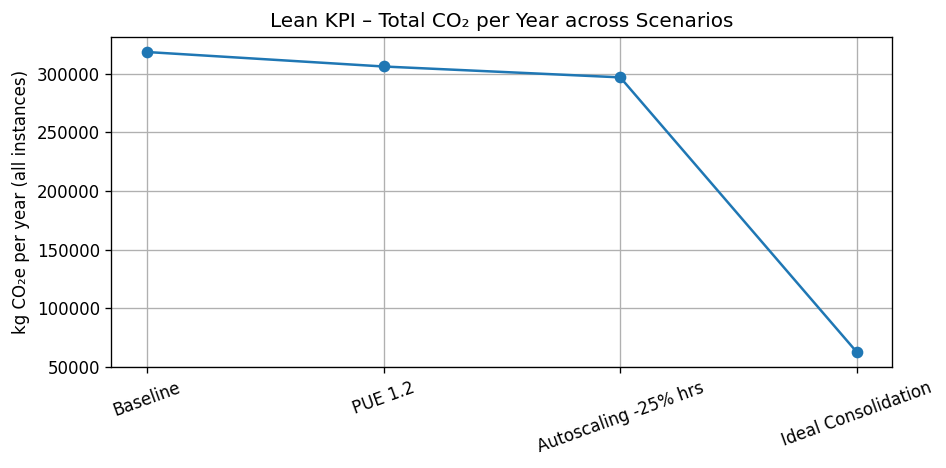

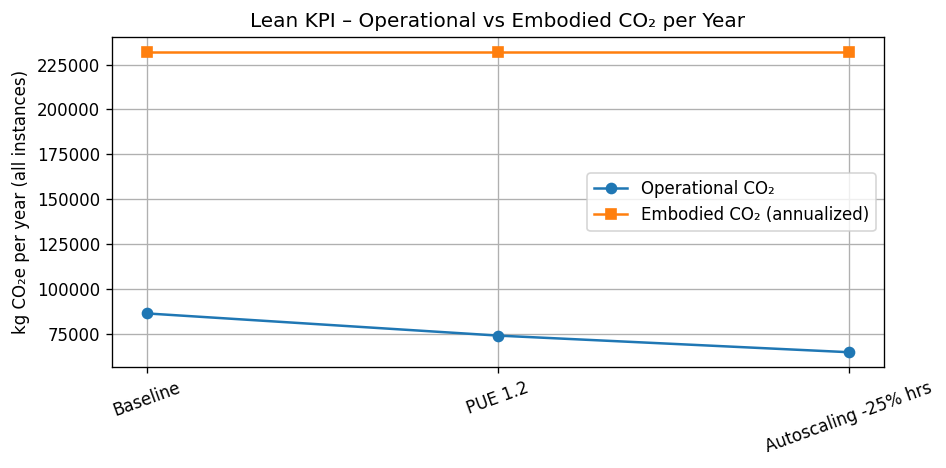


Done – full data analysis, ALL CPU platform graphs, Pareto, Lean scenarios and KPI trends are generated.


In [6]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

plt.rcParams["figure.dpi"] = 120


uploaded = files.upload()   # choose "Final_Cleaned_EC2_Instances (2).csv"
file_path = list(uploaded.keys())[0]
print("You uploaded:", file_path)

if not file_path.lower().endswith(".csv"):
    raise ValueError("Please upload the EC2 CSV file (not a PDF).")

df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)
print("Dataset loaded:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


HOURS_PER_YEAR = 8760      # hours per year
BASELINE_PUE   = 1.4       # baseline PUE
IMPROVED_PUE   = 1.2       # improved PUE scenario
EF_GRID        = 0.4       # kg CO2e / kWh
LIFETIME_YEARS = 4.0       # amortization period for Scope-3


COL_CPU_NAME   = [c for c in df.columns if "Platform CPU Name" in c][0]
COL_IDLE_WATT  = [c for c in df.columns if "RAMWatt" in c and "Idle" in c][0]
COL_FULL_WATT  = [c for c in df.columns if "Delta Full Machine" in c][0]

vcpu_candidates = [c for c in df.columns if "Instance vCPU" in c]
if not vcpu_candidates:
    raise KeyError("Could not find a column containing 'Instance vCPU'. Check df.columns.")
COL_VCPU = vcpu_candidates[0]

scope3_candidates = [c for c in df.columns if "Total Platform Scope 3 Emissions" in c]
if not scope3_candidates:
    raise KeyError("Could not find 'Total Platform Scope 3 Emissions' column. Check df.columns.")
COL_SCOPE3_TOT = scope3_candidates[0]

print("\n Using columns:")
print("CPU name  :", COL_CPU_NAME)
print("Idle watt :", COL_IDLE_WATT)
print("Full watt :", COL_FULL_WATT)
print("vCPU      :", COL_VCPU)
print("Scope 3   :", COL_SCOPE3_TOT)

for c in [COL_CPU_NAME, COL_IDLE_WATT, COL_FULL_WATT, COL_VCPU, COL_SCOPE3_TOT]:
    if c not in df.columns:
        raise KeyError(f"Column '{c}' not found in dataset. Check df.columns.")


print("\n⚡ STEP 3 – Energy calculations")


df["Estimated Power (W)"] = (df[COL_IDLE_WATT] + df[COL_FULL_WATT]) / 2.0


df["IT_kWh"] = (df["Estimated Power (W)"] / 1000.0) * HOURS_PER_YEAR


df["PUE"] = BASELINE_PUE
df["Total_kWh"] = df["IT_kWh"] * df["PUE"]

print("\n🔍 Sample energy rows:")
print(df[[COL_CPU_NAME, COL_IDLE_WATT, COL_FULL_WATT,
          "Estimated Power (W)", "IT_kWh", "Total_kWh"]].head())


print("\n STEP 4 – CO₂ calculations (kg CO₂e PER YEAR)")


df["Operational_CO2e_kg_per_year"] = df["Total_kWh"] * EF_GRID


df["Embodied_CO2e_kg_per_year"]   = df[COL_SCOPE3_TOT] / LIFETIME_YEARS


df["Total_CO2e_kg_per_year"]      = (
    df["Operational_CO2e_kg_per_year"] +
    df["Embodied_CO2e_kg_per_year"]
)

print("\n Sample CO₂ rows:")
print(df[[COL_CPU_NAME,
          "Operational_CO2e_kg_per_year",
          "Embodied_CO2e_kg_per_year",
          "Total_CO2e_kg_per_year"]].head())


total_operational_kg_per_year = df["Operational_CO2e_kg_per_year"].sum()
total_embodied_kg_per_year    = df["Embodied_CO2e_kg_per_year"].sum()
total_co2_kg_per_year         = df["Total_CO2e_kg_per_year"].sum()

print("\n Baseline CO₂ totals (one of each instance, PER YEAR):")
print(f"Operational CO₂ per year : {total_operational_kg_per_year:,.2f} kg")
print(f"Embodied CO₂ per year    : {total_embodied_kg_per_year:,.2f} kg")
print(f"TOTAL CO₂ per year       : {total_co2_kg_per_year:,.2f} kg")


print("\n STEP 6 – Aggregate by Platform CPU Name")

agg_cols = ["Operational_CO2e_kg_per_year",
            "Embodied_CO2e_kg_per_year",
            "Total_CO2e_kg_per_year"]

cpu_co2_total = (
    df.groupby(COL_CPU_NAME)[agg_cols]
      .sum()
      .sort_values("Total_CO2e_kg_per_year", ascending=False)
      .reset_index()
      .rename(columns={COL_CPU_NAME: "PlatformCPUName"})
)
cpu_co2_total["Rows"] = df.groupby(COL_CPU_NAME)[COL_CPU_NAME].count().values

print("\n📊 Total CO₂ per CPU platform (kg CO₂e per year):")
print(cpu_co2_total)

df["CO2e_kg_per_vCPU_per_year"] = df["Total_CO2e_kg_per_year"] / df[COL_VCPU]
cpu_eff = (
    df.groupby(COL_CPU_NAME)["CO2e_kg_per_vCPU_per_year"]
      .mean()
      .sort_values()
      .reset_index()
      .rename(columns={COL_CPU_NAME: "PlatformCPUName"})
)

print("\nMost CO₂-efficient CPUs (lowest kg CO₂e per vCPU per year):")
print(cpu_eff.head(10))


print("\n📈 STEP 7 – Pareto analysis")

pareto = cpu_co2_total.sort_values("Total_CO2e_kg_per_year", ascending=False)
pareto["Cumulative_CO2"] = pareto["Total_CO2e_kg_per_year"].cumsum()
pareto["Cumulative_pct"] = 100 * pareto["Cumulative_CO2"] / pareto["Total_CO2e_kg_per_year"].sum()

print("\n🔍 Pareto head (Top 10):")
print(pareto.head(10)[["PlatformCPUName", "Total_CO2e_kg_per_year", "Cumulative_pct"]])


top_n = min(15, len(pareto))
fig, ax1 = plt.subplots(figsize=(11,5))

ax1.bar(pareto["PlatformCPUName"].head(top_n),
        pareto["Total_CO2e_kg_per_year"].head(top_n))
ax1.set_xlabel("Platform CPU Name")
ax1.set_ylabel("Total CO₂ per year (kg)")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y")

ax2 = ax1.twinx()
ax2.plot(pareto["PlatformCPUName"].head(top_n),
         pareto["Cumulative_pct"].head(top_n),
         marker="o", color="red")
ax2.set_ylabel("Cumulative % of CO₂")
ax2.set_ylim(0, 110)

plt.title("Pareto Analysis of CO₂ by CPU Platform (Top 15)")
fig.tight_layout()
plt.show()


print("\n STEP 8 – Graphs for ALL CPU platforms")


plt.figure(figsize=(max(12, len(cpu_co2_total)*0.6), 5))
plt.bar(cpu_co2_total["PlatformCPUName"],
        cpu_co2_total["Total_CO2e_kg_per_year"])
plt.title("Total CO₂ per CPU Platform (ALL platforms, per year)")
plt.ylabel("kg CO₂e per year (all instances)")
plt.xlabel("Platform CPU Name")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


all_cpu = cpu_co2_total.set_index("PlatformCPUName")
all_cpu[["Operational_CO2e_kg_per_year",
         "Embodied_CO2e_kg_per_year"]].plot(
    kind="bar", stacked=True,
    figsize=(max(12, len(all_cpu)*0.6), 5)
)
plt.title("Operational vs Embodied CO₂ per CPU Platform (ALL, per year)")
plt.ylabel("kg CO₂e per year")
plt.xlabel("Platform CPU Name")
plt.xticks(rotation=45, ha="right")
plt.legend(title="CO₂ type")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,4))
plt.hist(df["Total_CO2e_kg_per_year"], bins=30)
plt.title("Distribution of Total CO₂ per Instance Type (per year)")
plt.xlabel("kg CO₂e per year (per instance type)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(11,5))
plt.bar(cpu_eff["PlatformCPUName"].head(10),
        cpu_eff["CO2e_kg_per_vCPU_per_year"].head(10))
plt.title("Most CO₂-Efficient CPU Platforms (kg CO₂e per vCPU per year)")
plt.ylabel("kg CO₂e per vCPU per year")
plt.xlabel("Platform CPU Name")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


print("\n STEP 9 – Lean Scenario 1: Improve PUE from 1.4 to 1.2")

df["Improved_PUE"] = IMPROVED_PUE
df["Improved_Total_kWh"] = df["IT_kWh"] * df["Improved_PUE"]
df["Improved_Operational_CO2e_kg_per_year"] = df["Improved_Total_kWh"] * EF_GRID
df["Improved_Total_CO2e_kg_per_year"] = (
    df["Improved_Operational_CO2e_kg_per_year"] +
    df["Embodied_CO2e_kg_per_year"]
)

total_operational_improved = df["Improved_Operational_CO2e_kg_per_year"].sum()
total_co2_improved_per_year = df["Improved_Total_CO2e_kg_per_year"].sum()

saved_pue = total_co2_kg_per_year - total_co2_improved_per_year
pct_pue = 100 * saved_pue / total_co2_kg_per_year

print(f"Total CO₂ per year (PUE 1.4) : {total_co2_kg_per_year:,.2f} kg")
print(f"Total CO₂ per year (PUE 1.2) : {total_co2_improved_per_year:,.2f} kg")
print(f"CO₂ saved by better PUE      : {saved_pue:,.2f} kg ({pct_pue:.1f}% reduction)")



print("\n STEP 10 – Lean Scenario 2: Autoscaling (25% fewer hours)")

reduced_hours = HOURS_PER_YEAR * 0.75
df["IT_kWh_reduced"] = (df["Estimated Power (W)"] / 1000.0) * reduced_hours
df["Total_kWh_reduced"] = df["IT_kWh_reduced"] * df["PUE"]
df["Operational_CO2e_kg_per_year_reduced"] = df["Total_kWh_reduced"] * EF_GRID
df["Total_CO2e_kg_per_year_reduced"] = (
    df["Operational_CO2e_kg_per_year_reduced"] +
    df["Embodied_CO2e_kg_per_year"]
)

total_operational_reduced = df["Operational_CO2e_kg_per_year_reduced"].sum()
total_co2_reduced_per_year = df["Total_CO2e_kg_per_year_reduced"].sum()

saved_runtime = total_co2_kg_per_year - total_co2_reduced_per_year
pct_runtime = 100 * saved_runtime / total_co2_kg_per_year

print(f"Total CO₂ per year after autoscaling : {total_co2_reduced_per_year:,.2f} kg")
print(f"CO₂ saved by runtime cut             : {saved_runtime:,.2f} kg ({pct_runtime:.1f}% reduction)")



print("\n STEP 11 – Lean Scenario 3: Ideal consolidation on best CPU")

total_vcpu = df[COL_VCPU].sum()
best_row = df.loc[df["CO2e_kg_per_vCPU_per_year"].idxmin()]
best_name = best_row[COL_CPU_NAME]
best_co2_per_vcpu_per_year = best_row["CO2e_kg_per_vCPU_per_year"]

ideal_total_co2_per_year = total_vcpu * best_co2_per_vcpu_per_year
saved_ideal = total_co2_kg_per_year - ideal_total_co2_per_year
pct_ideal = 100 * saved_ideal / total_co2_kg_per_year

print(f"Total vCPU in dataset                  : {total_vcpu}")
print(f"Best CPU platform (CO₂ per vCPU/year) : {best_name}")
print(f"Best CO₂ per vCPU per year            : {best_co2_per_vcpu_per_year:.2f} kg")
print(f"Idealized total CO₂ per year          : {ideal_total_co2_per_year:,.2f} kg")
print(f"Potential CO₂ reduction (upper bound) : {saved_ideal:,.2f} kg ({pct_ideal:.1f}% reduction)")


print("\n STEP 12 – KPI Dashboard & trend lines")

kpi_data = pd.DataFrame([
    {
        "Scenario": "Baseline",
        "Total_CO2e_kg_per_year": total_co2_kg_per_year,
        "Operational_CO2e_kg_per_year": total_operational_kg_per_year,
        "Embodied_CO2e_kg_per_year": total_embodied_kg_per_year
    },
    {
        "Scenario": "PUE 1.2",
        "Total_CO2e_kg_per_year": total_co2_improved_per_year,
        "Operational_CO2e_kg_per_year": total_operational_improved,
        "Embodied_CO2e_kg_per_year": total_embodied_kg_per_year
    },
    {
        "Scenario": "Autoscaling -25% hrs",
        "Total_CO2e_kg_per_year": total_co2_reduced_per_year,
        "Operational_CO2e_kg_per_year": total_operational_reduced,
        "Embodied_CO2e_kg_per_year": total_embodied_kg_per_year
    },
    {
        "Scenario": "Ideal Consolidation",
        "Total_CO2e_kg_per_year": ideal_total_co2_per_year,
        "Operational_CO2e_kg_per_year": np.nan,
        "Embodied_CO2e_kg_per_year": np.nan
    }
])

print("\nKPI table:")
print(kpi_data)


plt.figure(figsize=(8,4))
plt.plot(kpi_data["Scenario"], kpi_data["Total_CO2e_kg_per_year"],
         marker="o")
plt.title("Lean KPI – Total CO₂ per Year across Scenarios")
plt.ylabel("kg CO₂e per year (all instances)")
plt.xticks(rotation=20)
plt.grid(True)
plt.tight_layout()
plt.show()


subset = kpi_data.dropna(subset=["Operational_CO2e_kg_per_year"])
plt.figure(figsize=(8,4))
plt.plot(subset["Scenario"], subset["Operational_CO2e_kg_per_year"],
         marker="o", label="Operational CO₂")
plt.plot(subset["Scenario"], subset["Embodied_CO2e_kg_per_year"],
         marker="s", label="Embodied CO₂ (annualized)")
plt.title("Lean KPI – Operational vs Embodied CO₂ per Year")
plt.ylabel("kg CO₂e per year (all instances)")
plt.xticks(rotation=20)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nDone – full data analysis, ALL CPU platform graphs, Pareto, Lean scenarios and KPI trends are generated.")



 STEP 12 – KPI Dashboard (Global + Per-CPU)

🌐 Global KPI table (all instances combined):
                       Scenario  Total_CO2e_kg_per_year  \
0              Baseline PUE 1.4           318377.490632   
1                       PUE 1.2           306032.131256   
2          Autoscaling -25% hrs           296773.111724   
3  Ideal Consolidation (global)            62536.765894   

   Operational_CO2e_kg_per_year  Embodied_CO2e_kg_per_year  
0                  86417.515632                 231959.975  
1                  74072.156256                 231959.975  
2                  64813.136724                 231959.975  
3                           NaN                        NaN  


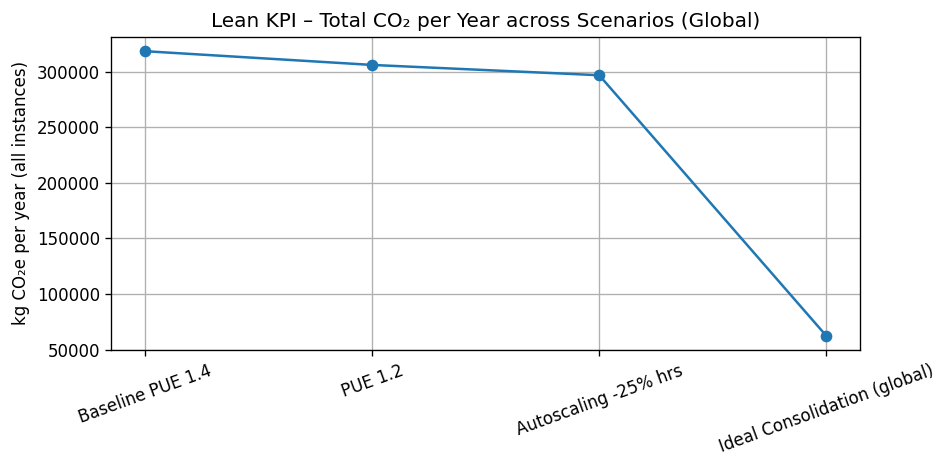

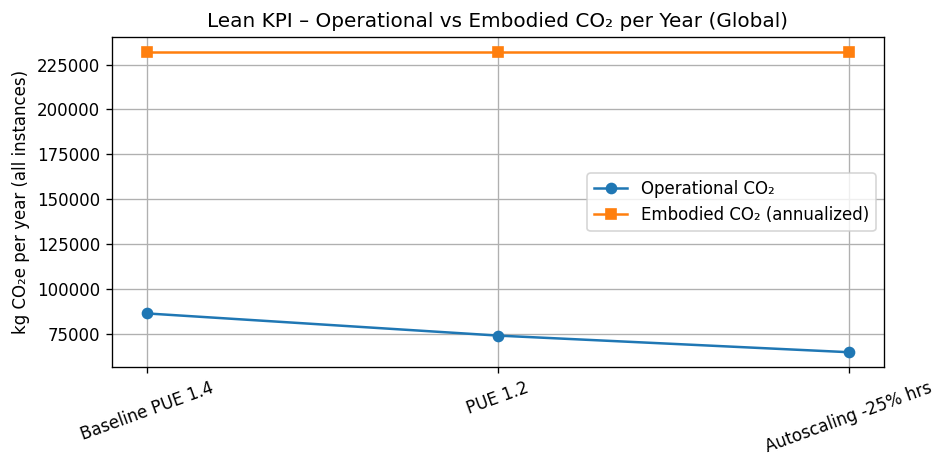


 Per-CPU KPI table – Baseline vs PUE 1.2 vs Autoscaling
    PlatformCPUName  Baseline_Total_CO2e_kg_per_year  \
0     Core i7-8700B                       303.134320   
1         EPYC 7571                     24894.276160   
2         EPYC 7R32                      8791.575520   
3          Graviton                      1637.053440   
4         Graviton2                     62567.567080   
5      Xeon E5-2650                      2962.916064   
6   Xeon E5-2651 v2                       791.694992   
7      Xeon E5-2665                      2565.683184   
8   Xeon E5-2666 v3                      3453.644160   
9      Xeon E5-2670                      8725.496256   
10  Xeon E5-2670 v2                     12090.449360   
11  Xeon E5-2676 v3                     13738.700272   
12  Xeon E5-2680 v2                      1933.162240   
13  Xeon E5-2686 v4                     48683.718784   
14  Xeon E7-8880 v3                     36917.708960   

    PUE12_Total_CO2e_kg_per_year  Autoscaling_

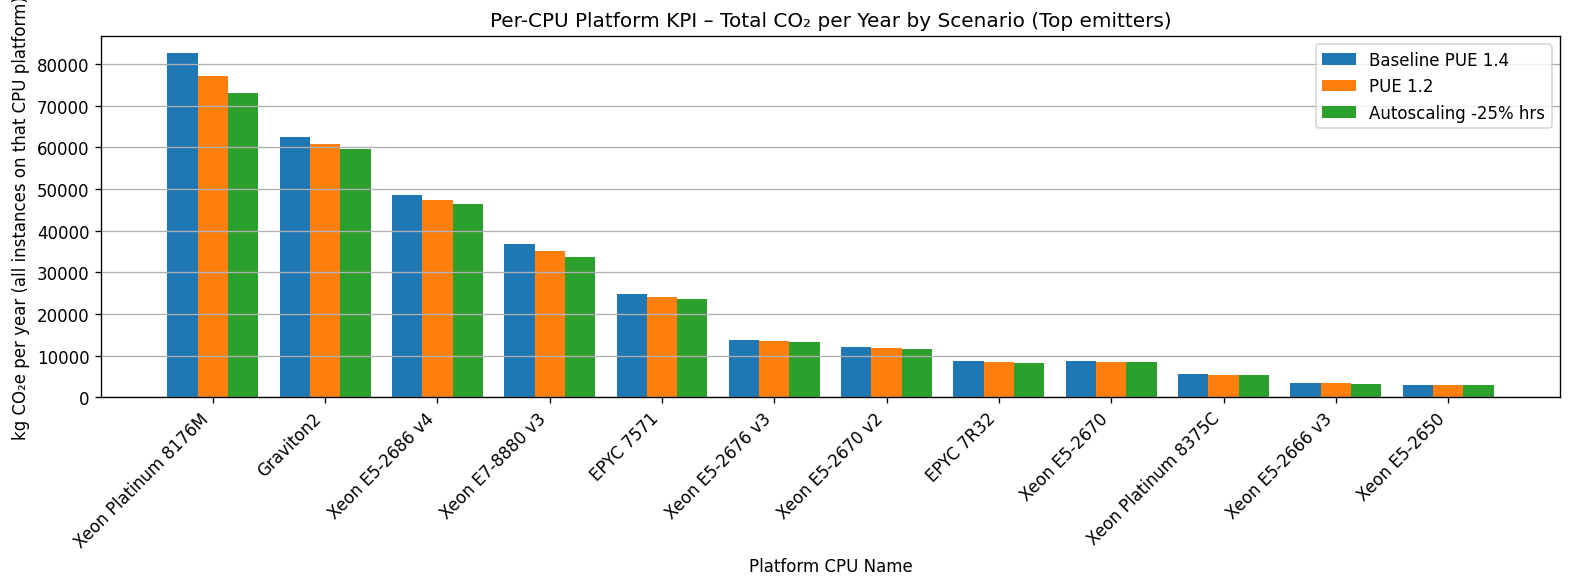


 KPI dashboard updated: global scenarios + per-CPU graphs with CPU platform names on the X-axis.


In [3]:

print("\n STEP 12 – KPI Dashboard (Global + Per-CPU)")

total_operational_kg_per_year = df["Operational_CO2e_kg_per_year"].sum()
total_embodied_kg_per_year    = df["Embodied_CO2e_kg_per_year"].sum()
total_co2_kg_per_year         = df["Total_CO2e_kg_per_year"].sum()


total_operational_improved    = df["Improved_Operational_CO2e_kg_per_year"].sum()
total_co2_improved_per_year   = df["Improved_Total_CO2e_kg_per_year"].sum()


total_operational_reduced     = df["Operational_CO2e_kg_per_year_reduced"].sum()
total_co2_reduced_per_year    = df["Total_CO2e_kg_per_year_reduced"].sum()


kpi_data = pd.DataFrame([
    {
        "Scenario": "Baseline PUE 1.4",
        "Total_CO2e_kg_per_year": total_co2_kg_per_year,
        "Operational_CO2e_kg_per_year": total_operational_kg_per_year,
        "Embodied_CO2e_kg_per_year": total_embodied_kg_per_year
    },
    {
        "Scenario": "PUE 1.2",
        "Total_CO2e_kg_per_year": total_co2_improved_per_year,
        "Operational_CO2e_kg_per_year": total_operational_improved,
        "Embodied_CO2e_kg_per_year": total_embodied_kg_per_year
    },
    {
        "Scenario": "Autoscaling -25% hrs",
        "Total_CO2e_kg_per_year": total_co2_reduced_per_year,
        "Operational_CO2e_kg_per_year": total_operational_reduced,
        "Embodied_CO2e_kg_per_year": total_embodied_kg_per_year
    },
    {
        "Scenario": "Ideal Consolidation (global)",
        "Total_CO2e_kg_per_year": ideal_total_co2_per_year,
        "Operational_CO2e_kg_per_year": np.nan,
        "Embodied_CO2e_kg_per_year": np.nan
    }
])

print("\n Global KPI table (all instances combined):")
print(kpi_data)


plt.figure(figsize=(8,4))
plt.plot(kpi_data["Scenario"], kpi_data["Total_CO2e_kg_per_year"],
         marker="o")
plt.title("Lean KPI – Total CO₂ per Year across Scenarios (Global)")
plt.ylabel("kg CO₂e per year (all instances)")
plt.xticks(rotation=20)
plt.grid(True)
plt.tight_layout()
plt.show()


subset = kpi_data.dropna(subset=["Operational_CO2e_kg_per_year"])
plt.figure(figsize=(8,4))
plt.plot(subset["Scenario"], subset["Operational_CO2e_kg_per_year"],
         marker="o", label="Operational CO₂")
plt.plot(subset["Scenario"], subset["Embodied_CO2e_kg_per_year"],
         marker="s", label="Embodied CO₂ (annualized)")
plt.title("Lean KPI – Operational vs Embodied CO₂ per Year (Global)")
plt.ylabel("kg CO₂e per year (all instances)")
plt.xticks(rotation=20)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("\n Per-CPU KPI table – Baseline vs PUE 1.2 vs Autoscaling")

cpu_kpi = (
    df.groupby(COL_CPU_NAME)
      .agg(
          Baseline_Total_CO2e_kg_per_year=("Total_CO2e_kg_per_year", "sum"),
          PUE12_Total_CO2e_kg_per_year=("Improved_Total_CO2e_kg_per_year", "sum"),
          Autoscaling_Total_CO2e_kg_per_year=("Total_CO2e_kg_per_year_reduced", "sum"),
          Instances=("Total_CO2e_kg_per_year", "count")
      )
      .reset_index()
      .rename(columns={COL_CPU_NAME: "PlatformCPUName"})
)

print(cpu_kpi.head(15))

print("\n Plotting KPI comparison per CPU platform (Baseline vs PUE 1.2 vs Autoscaling)…")


cpu_kpi_sorted = cpu_kpi.sort_values("Baseline_Total_CO2e_kg_per_year", ascending=False)

TOP_N_CPU = min(12, len(cpu_kpi_sorted))   # show top 12 CPU platforms
top_cpu_kpi = cpu_kpi_sorted.head(TOP_N_CPU)

x = np.arange(len(top_cpu_kpi))
width = 0.27

plt.figure(figsize=(max(12, TOP_N_CPU * 1.1), 5))

plt.bar(x - width,
        top_cpu_kpi["Baseline_Total_CO2e_kg_per_year"],
        width, label="Baseline PUE 1.4")
plt.bar(x,
        top_cpu_kpi["PUE12_Total_CO2e_kg_per_year"],
        width, label="PUE 1.2")
plt.bar(x + width,
        top_cpu_kpi["Autoscaling_Total_CO2e_kg_per_year"],
        width, label="Autoscaling -25% hrs")

plt.xticks(x, top_cpu_kpi["PlatformCPUName"], rotation=45, ha="right")
plt.ylabel("kg CO₂e per year (all instances on that CPU platform)")
plt.xlabel("Platform CPU Name")
plt.title("Per-CPU Platform KPI – Total CO₂ per Year by Scenario (Top emitters)")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print("\n KPI dashboard updated: global scenarios + per-CPU graphs with CPU platform names on the X-axis.")


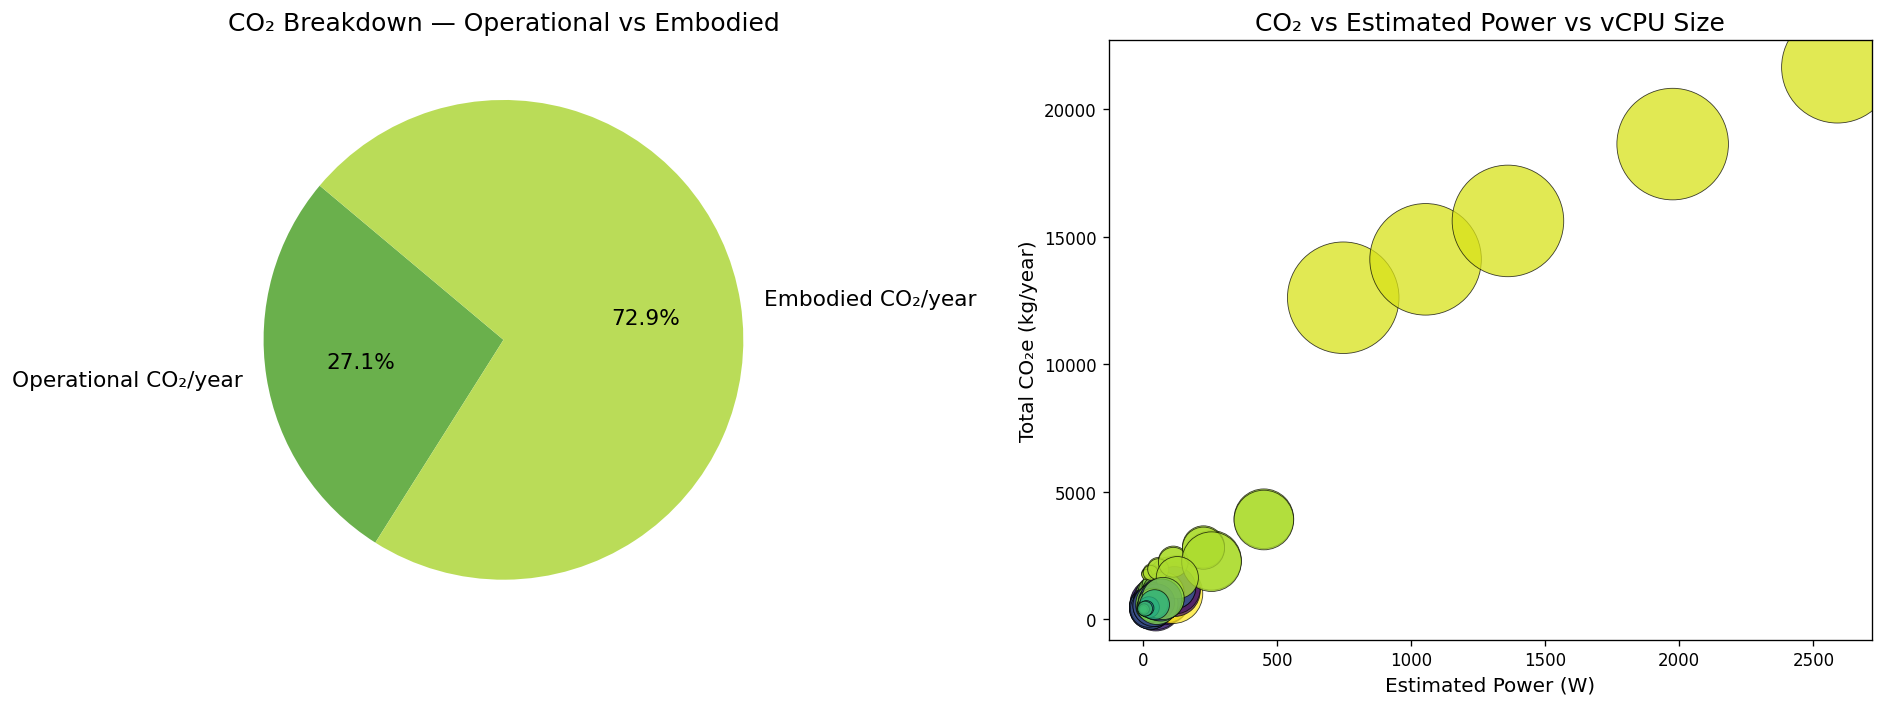

Building heatmap table ...


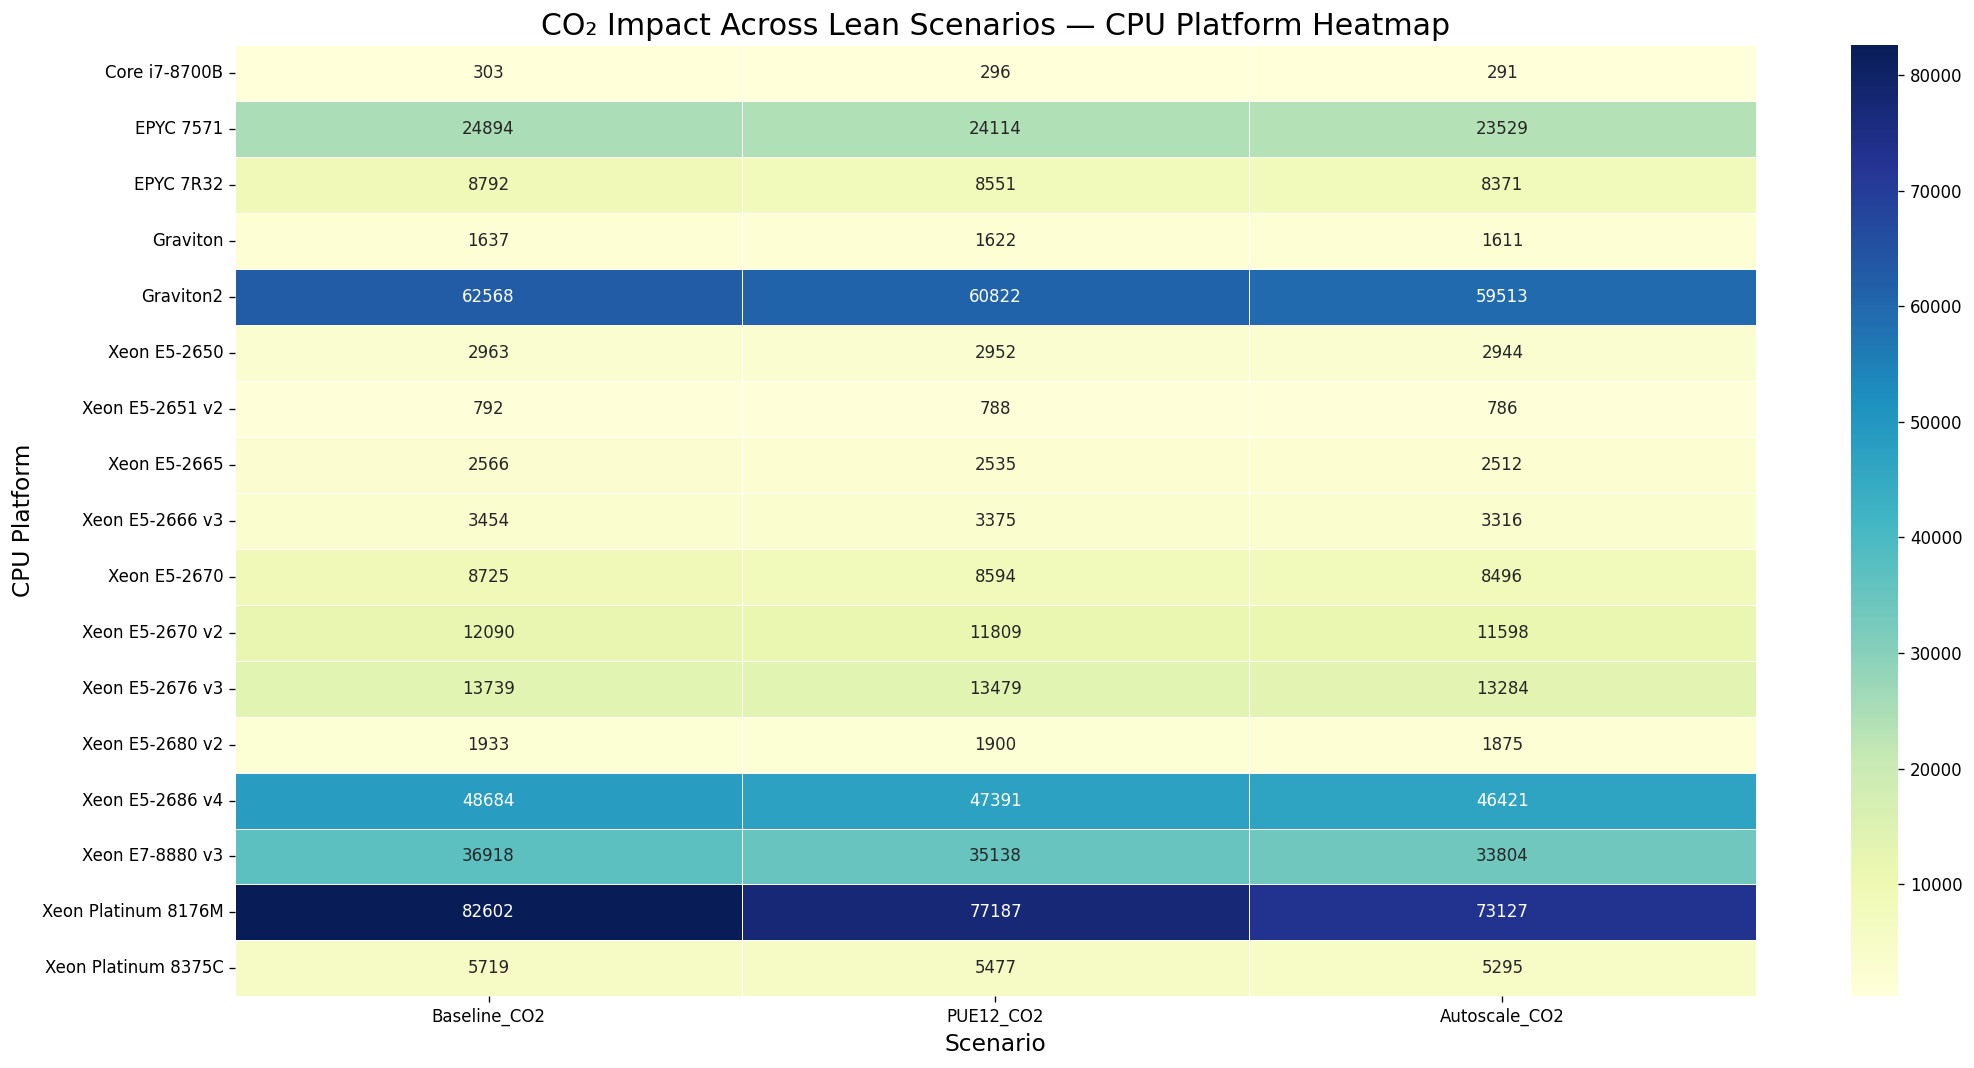


 Add-on KPI visuals generated: Pie | Scatter | Heatmap


In [2]:


import seaborn as sns
import matplotlib.pyplot as plt




operational_total = df["Operational_CO2e_kg_per_year"].sum()
embodied_total    = df["Embodied_CO2e_kg_per_year"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = ["Operational CO₂/year", "Embodied CO₂/year"]
sizes  = [operational_total, embodied_total]
colors = ["#6ab04c", "#badc58"]

axes[0].pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 13}
)
axes[0].set_title("CO₂ Breakdown — Operational vs Embodied", fontsize=15)


scatter = axes[1]

x = df["Estimated Power (W)"]
y = df["Total_CO2e_kg_per_year"]
sizes = df[COL_VCPU] * 10
colors = df[COL_CPU_NAME].astype("category").cat.codes

scatter.scatter(
    x, y,
    s=sizes,
    c=colors,
    cmap="viridis",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)

scatter.set_xlabel("Estimated Power (W)", fontsize=12)
scatter.set_ylabel("Total CO₂e (kg/year)", fontsize=12)
scatter.set_title("CO₂ vs Estimated Power vs vCPU Size", fontsize=15)

plt.tight_layout()
plt.show()



print("Building heatmap table ...")


cpu_kpi = df.groupby(COL_CPU_NAME).agg({
    "Total_CO2e_kg_per_year": "sum",
    "Improved_Total_CO2e_kg_per_year": "sum",
    "Total_CO2e_kg_per_year_reduced": "sum"
}).reset_index()

cpu_kpi = cpu_kpi.rename(columns={
    COL_CPU_NAME: "CPU",
    "Total_CO2e_kg_per_year": "Baseline_CO2",
    "Improved_Total_CO2e_kg_per_year": "PUE12_CO2",
    "Total_CO2e_kg_per_year_reduced": "Autoscale_CO2"
})

heat_df = cpu_kpi.set_index("CPU")[["Baseline_CO2", "PUE12_CO2", "Autoscale_CO2"]]

plt.figure(figsize=(18, 9))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("CO₂ Impact Across Lean Scenarios — CPU Platform Heatmap", fontsize=18)
plt.xlabel("Scenario", fontsize=14)
plt.ylabel("CPU Platform", fontsize=14)
plt.tight_layout()
plt.show()

print("\n Add-on KPI visuals generated: Pie | Scatter | Heatmap")
